# Tutorial: Building an Inflation Analysis Dashboard

This tutorial walks you through creating an inflation analysis dashboard using `econcharts`. By the end, we'll have built a multi-chart dashboard that visualizes:

- Historical inflation rates with Fed target reference
- Comparison of inflation vs Fed Funds Rate (monetary policy response)
- Recession periods and their relationship to inflation

## What You'll Learn

1. Fetching real economic data from FRED
2. Creating single charts with reference lines
3. Customizing colors, labels, and styling
4. Building multi-chart synchronized dashboards
5. Adding recession shading for historical context

---
## Step 1: Setup and Imports

First, let's import the necessary modules from `econcharts`.

In [1]:
# Core chart classes
from econcharts import EconChart, EconBoard, Data

# FRED data fetching utilities
from econcharts.fred import (
    fetch_inflation,      # CPI-based inflation rate
    fetch_fed_funds,      # Federal Funds Rate
    fetch_unemployment,   # Unemployment rate
    fetch_gdp,            # GDP growth
    list_series,          # See all available series
)

# Let's see what data is available
print("Available FRED series:")
print("-" * 50)
for name, info in list_series().items():
    print(f"{name:15} {info['name']:30} ({info['unit']})")

Available FRED series:
--------------------------------------------------
GDP             Real GDP Growth                (% Change)
CPI             Consumer Price Index           (Index)
INFLATION       Inflation Rate                 (% YoY)
UNEMPLOYMENT    Unemployment Rate              (%)
FEDFUNDS        Federal Funds Rate             (%)
TREASURY_10Y    10-Year Treasury Rate          (%)
SP500           S&P 500 Index                  (Index)


---
## Step 2: Fetch Inflation Data

The `fetch_inflation()` function retrieves the Consumer Price Index (CPI) year-over-year change from FRED. This is the most common measure of inflation.

Data is automatically cached locally, so subsequent calls are fast even without internet.

In [2]:
# Fetch inflation data starting from 1970 to see historical patterns
inf_dates, inf_values = fetch_inflation(start="1970-01-01")

print(f"Fetched {len(inf_dates)} months of inflation data")
print(f"Date range: {inf_dates[0].strftime('%Y-%m')} to {inf_dates[-1].strftime('%Y-%m')}")
print(f"")
print(f"Recent values:")
for date, value in zip(inf_dates[-5:], inf_values[-5:]):
    print(f"  {date.strftime('%Y-%m')}: {value:.2f}%")

Fetched 291 months of inflation data
Date range: 2000-01 to 2024-03

Recent values:
  2023-11: -0.20%
  2023-12: -0.10%
  2024-01: 0.54%
  2024-02: 0.62%
  2024-03: 0.65%


---
## Step 3: Create Your First Inflation Chart

Let's create a simple chart showing inflation over time. We'll use:
- `EconChart` - the main chart class
- `Data` - represents a data series with x values, y values, and styling

The minimum required parameters are `x`, `y`, and `name`.

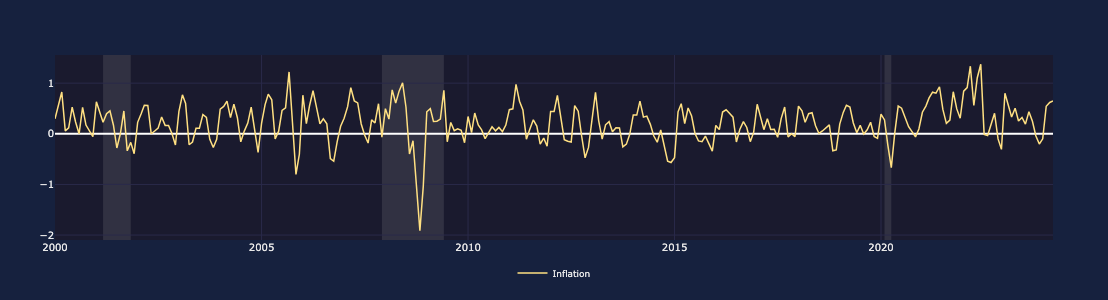

In [3]:
# Create a basic inflation chart
chart = EconChart(
    Data(x=inf_dates, y=inf_values, name='Inflation'),
)
chart.show()

That works, but it's missing context. Let's improve it by adding:
- A descriptive title
- Y-axis label
- A reference line at 2% (the Fed's inflation target)

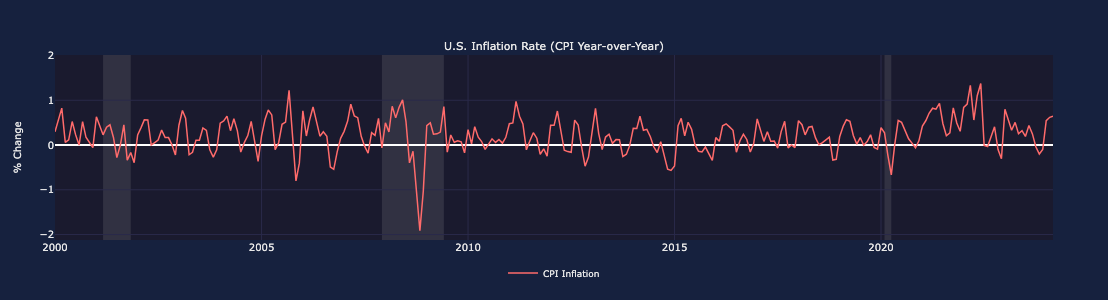

In [4]:
# Improved chart with title, label, and reference line
chart = EconChart(
    Data(x=inf_dates, y=inf_values, name='CPI Inflation', color='coral'),
    title='U.S. Inflation Rate (CPI Year-over-Year)',
    y_label='% Change',
    horizontal_line=2,  # Fed's 2% target
    horizontal_line_color='teal',
)
chart.show()

**Key observations:**
- The gray shaded areas are **recession periods** (shown by default)
- The dashed horizontal line marks the Fed's 2% inflation target
- Notice the high inflation periods in the 1970s-80s and 2021-2023
- Hover over the chart to see exact values

---
## Step 4: Focus on Recent History

For analyzing recent inflation trends, let's zoom in to the 2000s. We can either:
1. Fetch only recent data with the `start` parameter
2. Use `x_range` to constrain the view

Let's fetch fresh data starting from 2000.

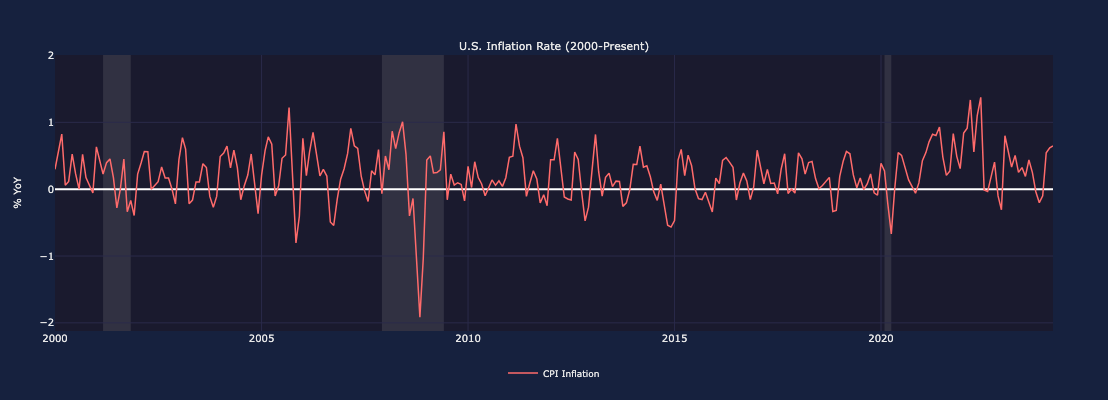

In [5]:
# Fetch data from 2000 onwards for clearer recent analysis
inf_dates, inf_values = fetch_inflation(start="2000-01-01")

chart = EconChart(
    Data(x=inf_dates, y=inf_values, name='CPI Inflation', color='coral'),
    title='U.S. Inflation Rate (2000-Present)',
    y_label='% YoY',
    horizontal_line=2,
    horizontal_line_color='teal',
)
chart.show(height=400)

---
## Step 5: Add the Fed Funds Rate for Context

To understand inflation, it helps to see the Fed's monetary policy response. The Federal Funds Rate is the Fed's primary tool for controlling inflation.

Let's add it to our chart.

In [6]:
# Fetch Fed Funds Rate data
fed_dates, fed_values = fetch_fed_funds(start="2000-01-01")

print(f"Fed Funds: {len(fed_dates)} months")
print(f"Current rate: {fed_values[-1]:.2f}%")

Fed Funds: 312 months
Current rate: 3.72%


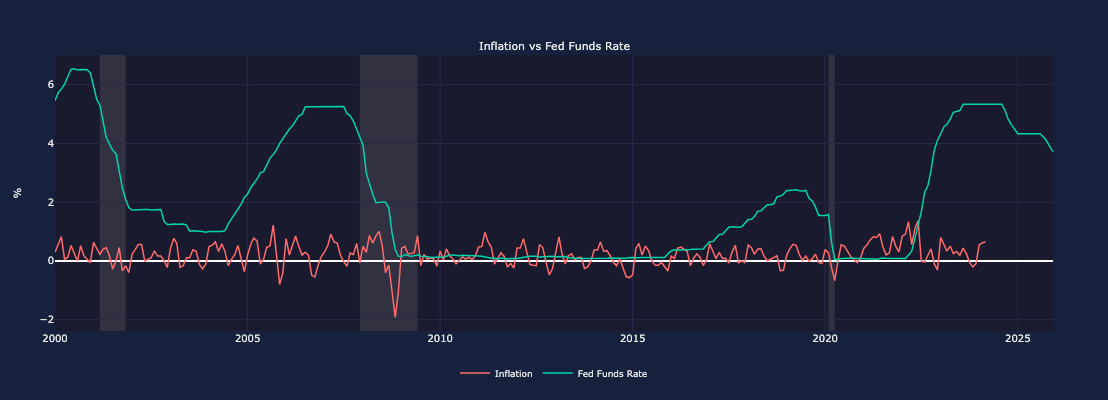

In [7]:
# Chart with both inflation and Fed Funds Rate
chart = EconChart(
    Data(x=inf_dates, y=inf_values, name='Inflation', color='coral'),
    Data(x=fed_dates, y=fed_values, name='Fed Funds Rate', color='teal'),
    title='Inflation vs Fed Funds Rate',
    y_label='%',
    horizontal_line=2,
    horizontal_line_color='gray',
)
chart.show(height=400)

**Analysis:**
- When inflation rises above target, the Fed typically raises rates
- Notice how the Fed cut rates to near-zero during the 2008 recession and COVID-19
- The 2022-2023 rate hikes were a response to high inflation

---
## Step 6: Create a Multi-Chart Dashboard

For deeper analysis, let's separate the metrics into their own charts but keep them synchronized. `EconBoard` combines multiple `EconChart` objects into a dashboard with:
- Synchronized x-axis (zoom one, zoom all)
- Unified crosshair across all charts
- Consistent recession shading

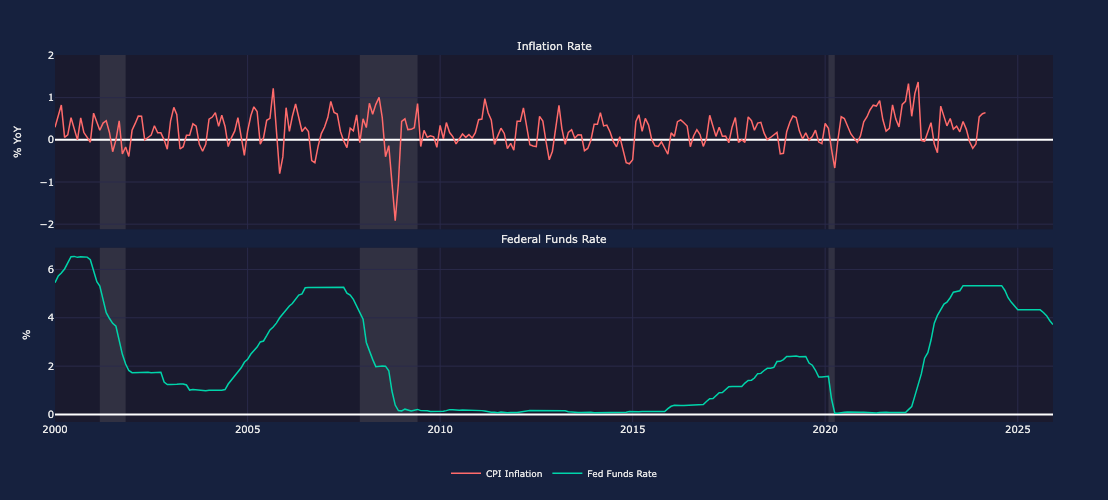

In [8]:
# Create individual charts
inflation_chart = EconChart(
    Data(x=inf_dates, y=inf_values, name='CPI Inflation', color='coral'),
    title='Inflation Rate',
    y_label='% YoY',
    horizontal_line=2,
    horizontal_line_color='teal',
)

fed_chart = EconChart(
    Data(x=fed_dates, y=fed_values, name='Fed Funds Rate', color='teal'),
    title='Federal Funds Rate',
    y_label='%',
    horizontal_line=0,
)

# Combine into a dashboard
board = EconBoard(
    inflation_chart,
    fed_chart,
    height=500,
)
board.show()

**Try it:** Hover over either chart - the crosshair appears on both!

---
## Step 7: Add Economic Context with More Indicators

A complete inflation analysis should consider the broader economy. Let's add:
- **Unemployment** - high unemployment often leads to lower inflation (Phillips Curve)
- **GDP Growth** - economic growth can drive inflation

In [9]:
# Fetch additional economic data
unemp_dates, unemp_values = fetch_unemployment(start="2000-01-01")
gdp_dates, gdp_values = fetch_gdp(start="2000-01-01")

print(f"Unemployment: {len(unemp_dates)} months")
print(f"GDP: {len(gdp_dates)} quarters")

Unemployment: 311 months
GDP: 103 quarters


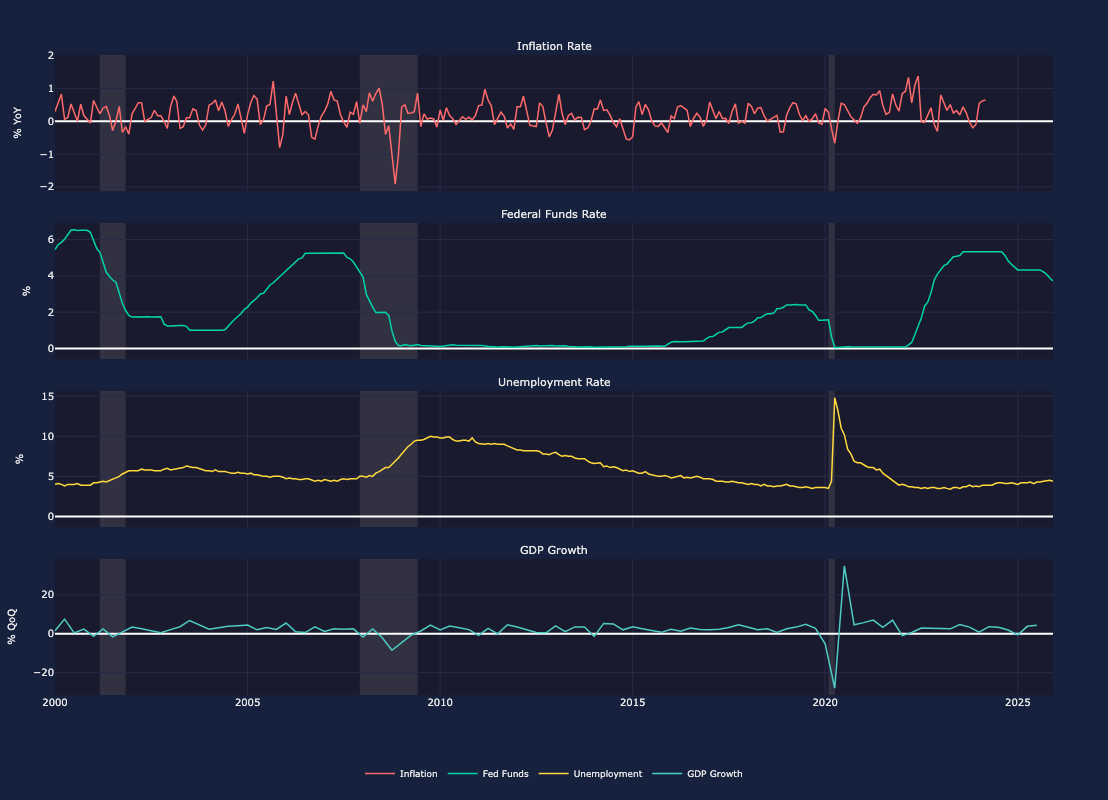

In [10]:
# Build individual charts for each indicator
inflation_chart = EconChart(
    Data(x=inf_dates, y=inf_values, name='Inflation', color='coral'),
    title='Inflation Rate',
    y_label='% YoY',
    horizontal_line=2,
)

fed_chart = EconChart(
    Data(x=fed_dates, y=fed_values, name='Fed Funds', color='teal'),
    title='Federal Funds Rate',
    y_label='%',
)

unemployment_chart = EconChart(
    Data(x=unemp_dates, y=unemp_values, name='Unemployment', color='gold'),
    title='Unemployment Rate',
    y_label='%',
)

gdp_chart = EconChart(
    Data(x=gdp_dates, y=gdp_values, name='GDP Growth', color='sky'),
    title='GDP Growth',
    y_label='% QoQ',
    horizontal_line=0,
)

# Create the full dashboard
board = EconBoard(
    inflation_chart,
    fed_chart,
    unemployment_chart,
    gdp_chart,
    height=800,
    legend='bottom',
)
board.show()

---
## Step 8: Customize the Appearance

Let's polish our dashboard with:
- An overall title
- Custom recession shading color
- Adjusted spacing

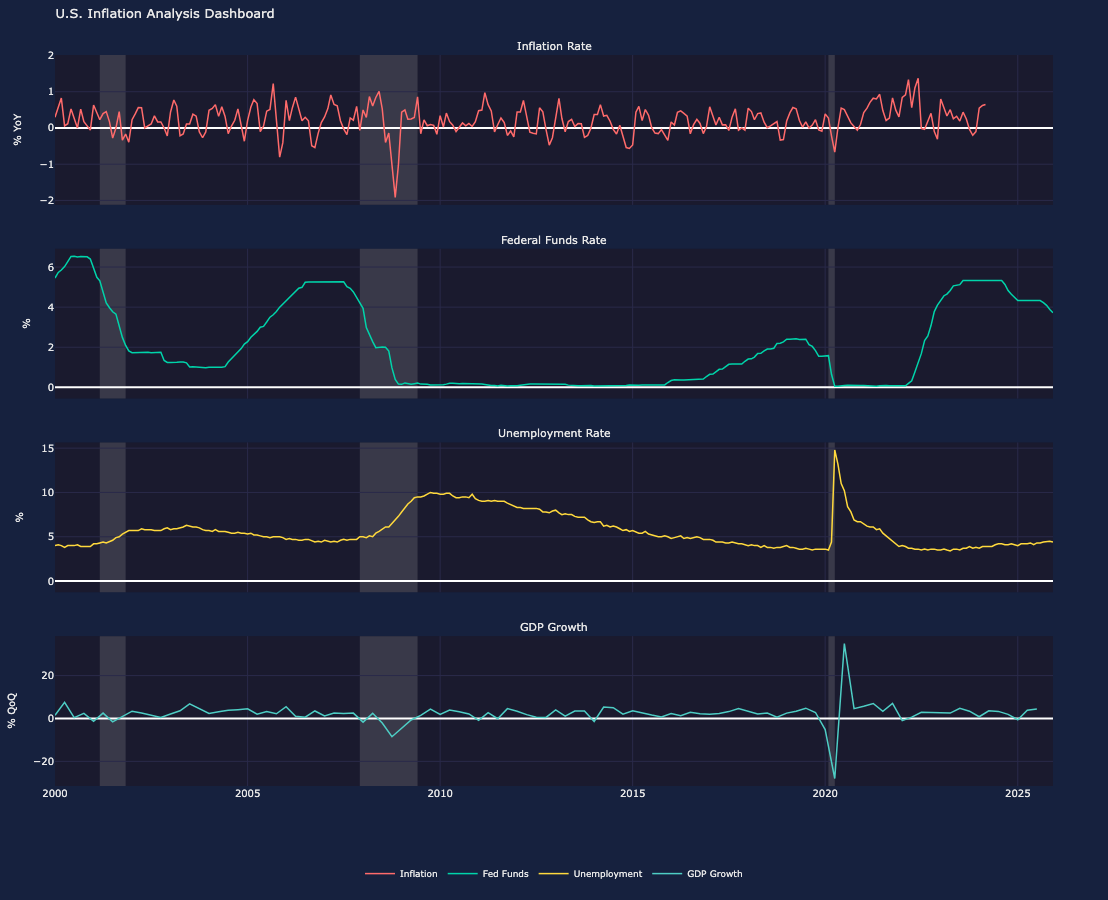

In [11]:
# Final polished dashboard
board = EconBoard(
    inflation_chart,
    fed_chart,
    unemployment_chart,
    gdp_chart,
    title='U.S. Inflation Analysis Dashboard',
    height=900,
    spacing=0.06,
    legend='bottom',
    legend_orientation='horizontal',
    recession_color='gray',
    recession_opacity=0.2,
    crosshair=True,
    crosshair_color='white',
)
board.show()

---
## Step 9: Export Your Dashboard

You can export your dashboard as an interactive HTML file to share with others.

In [12]:
# Export to HTML
board.to_html('inflation_dashboard.html')
print("Dashboard exported to: inflation_dashboard.html")
print("Open this file in any web browser to view the interactive chart.")

Dashboard exported to: inflation_dashboard.html
Open this file in any web browser to view the interactive chart.


---
## Step 10: Historical Hyperinflation Analysis

Let's look at the full historical picture including the high inflation of the 1970s-80s.

In [13]:
# Fetch long-term historical data
inf_dates_long, inf_values_long = fetch_inflation(start="1960-01-01")
fed_dates_long, fed_values_long = fetch_fed_funds(start="1960-01-01")

print(f"Historical data from {inf_dates_long[0].year}")

Historical data from 2000


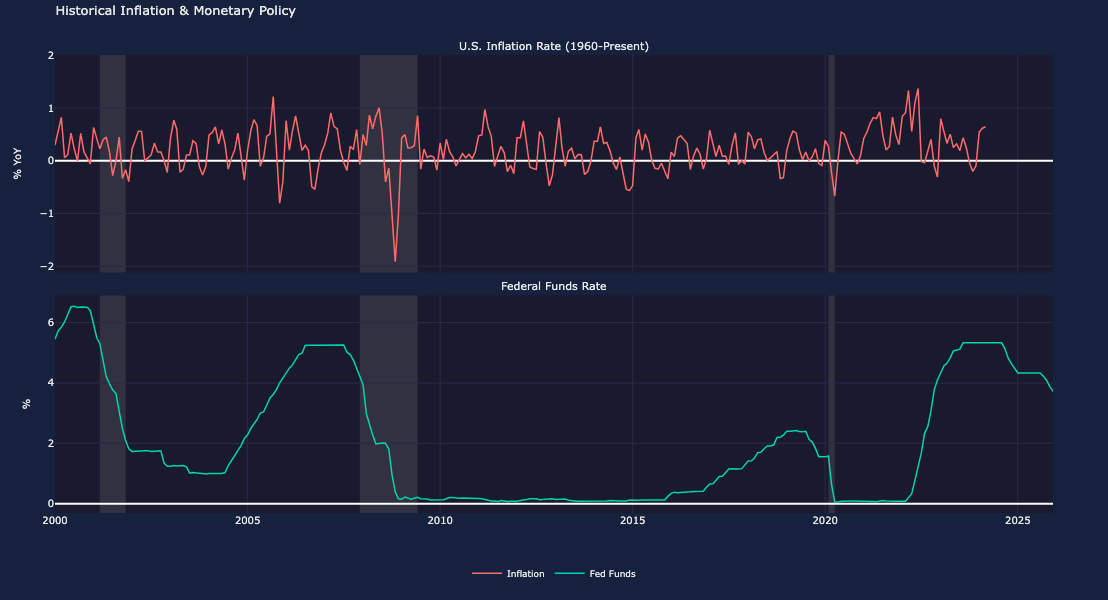

In [14]:
# Historical inflation chart
inflation_long = EconChart(
    Data(x=inf_dates_long, y=inf_values_long, name='Inflation', color='coral'),
    title='U.S. Inflation Rate (1960-Present)',
    y_label='% YoY',
    horizontal_line=2,
    horizontal_line_color='teal',
)

fed_long = EconChart(
    Data(x=fed_dates_long, y=fed_values_long, name='Fed Funds', color='teal'),
    title='Federal Funds Rate',
    y_label='%',
)

board = EconBoard(
    inflation_long,
    fed_long,
    title='Historical Inflation & Monetary Policy',
    height=600,
)
board.show()

**Historical Analysis:**

1. **1970s Stagflation**: Inflation peaked above 14% due to oil shocks and loose monetary policy
2. **Volcker Shock (1980-82)**: Fed Chair Paul Volcker raised rates to nearly 20% to break inflation
3. **Great Moderation (1985-2007)**: Stable inflation around 2-4%
4. **2008 Financial Crisis**: Deflation fears led to zero interest rates
5. **2021-2023 Inflation Surge**: Post-COVID supply chain issues and stimulus drove inflation to 9%

---
## Step 11: Calculate Real Interest Rates

The **real interest rate** (Fed Funds Rate minus Inflation) shows whether monetary policy is truly restrictive or accommodative.

In [15]:
# Calculate real interest rate
# We need to align the dates since inflation and fed funds may have different frequencies

# Create a dict for quick inflation lookup
inf_dict = {d.strftime('%Y-%m'): v for d, v in zip(inf_dates, inf_values)}

# Calculate real rate where we have both values
real_dates = []
real_values = []

for d, fed_rate in zip(fed_dates, fed_values):
    key = d.strftime('%Y-%m')
    if key in inf_dict:
        real_rate = fed_rate - inf_dict[key]
        real_dates.append(d)
        real_values.append(real_rate)

print(f"Calculated {len(real_dates)} real rate observations")
print(f"Current real rate: {real_values[-1]:.2f}%")

Calculated 291 real rate observations
Current real rate: 4.68%


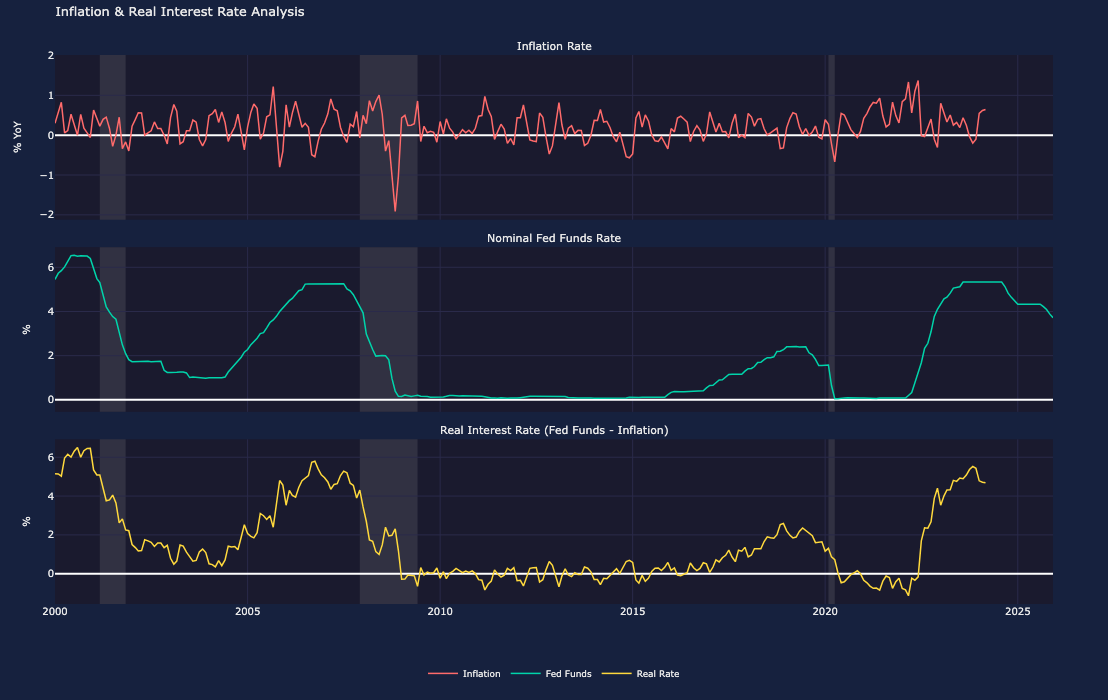

In [16]:
# Dashboard with real interest rate
inflation_chart = EconChart(
    Data(x=inf_dates, y=inf_values, name='Inflation', color='coral'),
    title='Inflation Rate',
    y_label='% YoY',
    horizontal_line=2,
)

fed_chart = EconChart(
    Data(x=fed_dates, y=fed_values, name='Fed Funds', color='teal'),
    title='Nominal Fed Funds Rate',
    y_label='%',
)

real_chart = EconChart(
    Data(x=real_dates, y=real_values, name='Real Rate', color='gold'),
    title='Real Interest Rate (Fed Funds - Inflation)',
    y_label='%',
    horizontal_line=0,
    horizontal_line_color='white',
)

board = EconBoard(
    inflation_chart,
    fed_chart,
    real_chart,
    title='Inflation & Real Interest Rate Analysis',
    height=700,
)
board.show()

**Key Insight:**
- When real rates are **negative**, monetary policy is accommodative (stimulating the economy)
- When real rates are **positive**, monetary policy is restrictive (slowing the economy)
- Notice how real rates were deeply negative during 2021-2022, contributing to inflation

---
## Summary

In this tutorial, we learned how to:

1. **Fetch data** from FRED using `fetch_inflation()`, `fetch_fed_funds()`, etc.
2. **Create charts** with `EconChart` and `Data` classes
3. **Add context** with titles, labels, and reference lines
4. **Build dashboards** with `EconBoard` for multi-chart layouts
5. **Customize appearance** with colors, spacing, and recession shading
6. **Export** interactive HTML files
7. **Calculate derived metrics** like real interest rates

### Next Steps

- Explore other FRED series (S&P 500, Treasury yields, etc.)
- Try different color schemes with the `colors` parameter
- Create your own econometrics dashboards